[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DVPombo/SOLETE/blob/main/examples/03_pv_forecasting.ipynb)

# 03 — Simple PV power forecasting

A small, teaching-scale forecasting demo for `P_Solar[kW]`: a naive persistence
baseline, plus one simple ML model, compared on the same held-out data. This is not a
benchmark — the point is to show the *shape* of a forecasting workflow on SOLETE,
including one thing that's easy to get wrong on this particular dataset: **evaluating
against rows where the "ground truth" is itself model output** (see the QC section
below).

Uses `SOLETE_sample.h5`, same as the previous two notebooks.

In [ ]:
# --- Colab / local setup -------------------------------------------------
# This cell makes the notebook runnable both from a local clone (the usual
# case) and from the "Open in Colab" badge above, where nothing but this
# .ipynb file exists yet in the Colab VM.
#
# 1. If `Functions.py` isn't found one directory up, we're not inside a local
#    clone of the repo (e.g. Colab) -- shallow-clone it once and move into
#    examples/, so the rest of this notebook (written assuming it runs from
#    examples/) works unmodified.
# 2. Either way, check whether the sample file this notebook needs is already
#    present before fetching it -- so re-running locally never re-downloads it.
import os
import subprocess
import urllib.request

ORG = "DVPombo"
REPO = "SOLETE"
BRANCH = "main"
SAMPLE_FILE = "SOLETE_sample.h5"
REPO_URL = "https://github.com/" + ORG + "/" + REPO + ".git"

if not os.path.exists("../Functions.py"):
    if not os.path.isdir(REPO):
        subprocess.run(
            ["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL],
            check=True,
        )
    os.chdir(REPO + "/examples")
    print("Cloned " + ORG + "/" + REPO + "@" + BRANCH + " and switched into examples/.")

# Check-before-fetch: the sample file may already be sitting in examples/
# (its real location in this repo) or one level up (where the loader calls
# below expect it) -- only hit the network if it's in neither place.
sample_here = os.path.exists(SAMPLE_FILE)
sample_up = os.path.exists("../" + SAMPLE_FILE)

if sample_here or sample_up:
    print(SAMPLE_FILE + " already present locally, skipping download.")
else:
    url = "https://raw.githubusercontent.com/" + ORG + "/" + REPO + "/" + BRANCH + "/examples/" + SAMPLE_FILE
    dest = "../" + SAMPLE_FILE
    print(SAMPLE_FILE + " not found locally, fetching from GitHub...")
    urllib.request.urlretrieve(url, dest)
    print("Done.")


In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

from Functions import import_SOLETE_sample, import_PV_WT_data

pd.set_option('display.max_columns', None)
%matplotlib inline

Control_Var = {'OriginalFeatures': [], 'PossibleFeatures': []}
PVinfo, WTinfo = import_PV_WT_data()
df = import_SOLETE_sample('../SOLETE_sample.h5', Control_Var, PVinfo, WTinfo)

I0000 00:00:1789171484.544790     365 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789171484.581695     365 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1789171485.759362     365 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


SOLETE sample was imported from: ../SOLETE_sample.h5
    2160 rows, 2018-12-01 00:00:00 .. 2019-02-28 23:00:00

QC flags applied: {'Azimuth[deg]_qc': 2150, 'Elevation[deg]_qc': 2151, 'Pressure[mbar]_qc': 2147, 'HUMIDITY[%]_qc': 42, 'WIND_DIR[deg]_qc': 31} 

Expanding SOLETE with King's PV Performance Model
    Cleaning noise and curtailment from active power production
    QC flag (substitution): {'P_Solar[kW]_qc': 1272}
    Smoothing zeros

Adding new Types with codes: []

SOLETE has been successfully expanded from: 11 to: 22 features.




## Choosing a persistence baseline

The two standard naive baselines for a time series are:

- **"next value = last value"** (`t-1` persistence) — simplest, but for solar power
  it does badly right at sunrise/sunset, since it just carries the previous hour's
  value forward across a transition where the real value is changing fast.
- **"next value = same hour yesterday"** (`t-24` persistence) — respects the strong
  diurnal cycle solar power has (zero at night, a bell curve during the day), so it
  gets the sunrise/sunset timing right for free.

Solar power's diurnal cycle is the dominant pattern in the signal, so **we use the
`t-24` (same-hour-yesterday) baseline** here — it's the fairer naive comparison for
this particular variable.

In [2]:
target = 'P_Solar[kW]'

data = df[[target, f'{target}_qc', 'POA Irr[kW1m2]', 'TEMPERATURE[degC]',
           'WIND_SPEED[m1s]']].copy()

# Lag features + the t-24 persistence prediction itself
data['lag_1'] = data[target].shift(1)
data['lag_24'] = data[target].shift(24)
data['persistence_pred'] = data['lag_24']

data = data.dropna()
print(data.shape)
data.head()

(2136, 8)


,P_Solar[kW],P_Solar[kW]_qc,POA Irr[kW1m2],TEMPERATURE[degC],WIND_SPEED[m1s],lag_1,lag_24,persistence_pred
2018-12-02 00:00:00,0.000000,6,0.000025,5.374722,3.397500,0.001915,0.0,0.0
2018-12-02 01:00:00,0.000000,6,0.000000,5.149889,3.383861,0.000000,0.0,0.0
2018-12-02 02:00:00,0.000000,6,0.000000,5.357444,3.923500,0.000000,0.0,0.0
2018-12-02 03:00:00,0.004637,0,0.000582,5.448500,4.381583,0.000000,0.0,0.0
2018-12-02 04:00:00,0.000000,6,0.000092,5.376028,3.705167,0.004637,0.0,0.0


## Respecting the Phase 2 QC flag before evaluating

`P_Solar[kW]_qc == 6` marks rows where the "measured" value was actually **replaced by
King's PV performance model estimate** (`Pac`) during loading, because the raw sensor
reading looked implausible relative to the model (see `02_data_quality.ipynb`). On this
sample, that's a substantial share of all rows:

In [3]:
subst_share = (data[f'{target}_qc'] == 6).mean()
print(f"{subst_share:.1%} of usable rows have a model-substituted P_Solar[kW]")

58.9% of usable rows have a model-substituted P_Solar[kW]


If we evaluated forecast accuracy against those rows as if they were ground truth, we'd
be comparing one model's forecast against a **different model's output** — the physics
model's estimate, not a real measurement. Any agreement (or disagreement) there tells us
about how similar the two models are, not about real-world forecast accuracy. That's
circular, and it's a real, documented issue specific to this dataset (`P_Solar[kW]_qc`,
`KNOWN_ISSUES.md` finding #6) — not a generic time-series caveat.

**So: we evaluate error only on rows where `P_Solar[kW]_qc == 0`** (the value is the
original sensor reading, unmodified). Substituted rows still get a forecast from both
methods below — we just don't score against them.

In [4]:
eval_mask = data[f'{target}_qc'] == 0
print(f"Evaluating on {eval_mask.sum()} of {len(data)} rows "
      f"({eval_mask.mean():.1%}) with a real (non-substituted) ground-truth value.")

Evaluating on 877 of 2136 rows (41.1%) with a real (non-substituted) ground-truth value.


## Train/test split and the simple model

A plain chronological 80/20 split (no shuffling — this is a time series), and a small `RandomForestRegressor` using the lag features plus same-timestamp meteorological readings (a simplification: a real forecasting system would use *forecast* weather, not the actual observed value, as an input — fine for a teaching demo, not fine for production).

In [5]:
feature_cols = ['lag_1', 'lag_24', 'POA Irr[kW1m2]', 'TEMPERATURE[degC]', 'WIND_SPEED[m1s]']
X = data[feature_cols]
y = data[target]

split = int(len(data) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]
persistence_test = data['persistence_pred'].iloc[split:]
eval_mask_test = eval_mask.iloc[split:]

print(f"Train: {len(X_train)} rows, Test: {len(X_test)} rows "
      f"({eval_mask_test.sum()} evaluable in test set)")

model = RandomForestRegressor(n_estimators=50, max_depth=8, random_state=0)
model.fit(X_train, y_train)
rf_pred = pd.Series(model.predict(X_test), index=X_test.index)

Train: 1708 rows, Test: 428 rows (205 evaluable in test set)


## Results

In [6]:
def score(y_true, y_pred, mask):
    yt, yp = y_true[mask], y_pred[mask]
    return mean_absolute_error(yt, yp), root_mean_squared_error(yt, yp)

pers_mae, pers_rmse = score(y_test, persistence_test, eval_mask_test)
rf_mae, rf_rmse = score(y_test, rf_pred, eval_mask_test)

results = pd.DataFrame({
    'MAE [kW]': [pers_mae, rf_mae],
    'RMSE [kW]': [pers_rmse, rf_rmse],
}, index=['Persistence (t-24)', 'Random Forest'])
results

,MAE [kW],RMSE [kW]
Persistence (t-24),1.558470,2.257988
Random Forest,0.081865,0.201828


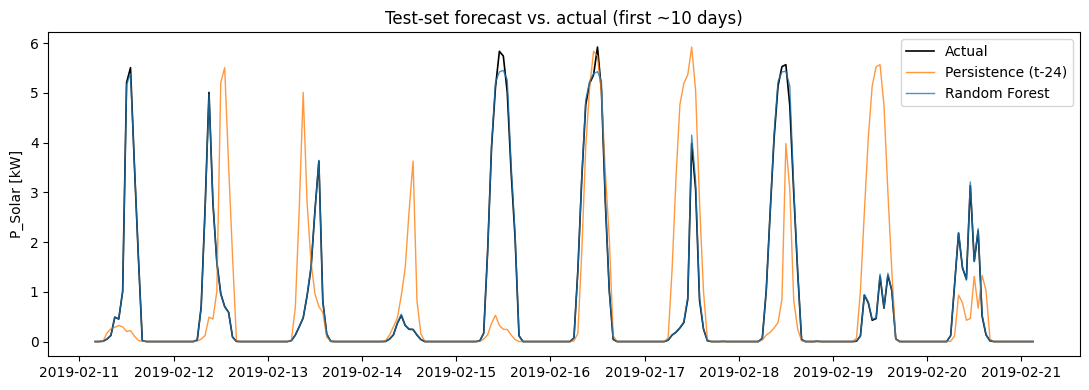

In [7]:
fig, ax = plt.subplots(figsize=(11, 4))
plot_slice = slice(0, 240)  # first ~10 days of the test set
ax.plot(y_test.index[plot_slice], y_test.iloc[plot_slice], label='Actual', color='black', linewidth=1.2)
ax.plot(y_test.index[plot_slice], persistence_test.iloc[plot_slice], label='Persistence (t-24)',
        color='tab:orange', linewidth=1, alpha=0.8)
ax.plot(y_test.index[plot_slice], rf_pred.iloc[plot_slice], label='Random Forest',
        color='tab:blue', linewidth=1, alpha=0.8)
ax.set_ylabel('P_Solar [kW]')
ax.set_title('Test-set forecast vs. actual (first ~10 days)')
ax.legend()
fig.tight_layout()
plt.show()

## Takeaway

The Random Forest, using same-timestamp meteorological readings as extra features, beats
plain `t-24` persistence — which makes sense, since persistence has no way to react to a
particular day being cloudier or sunnier than the day before, while the RF can use the
actual irradiance reading. Whether that gap justifies the added complexity for a given
use case is a judgment call, but at least now there's a concrete number to make it with,
computed only against real (non-substituted) measurements.